In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv(r"C:\Users\A\Downloads\retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())

(1000, 9)
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
0


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.drop_duplicates()
df = df.dropna(subset=["Customer ID"])
print(df.shape)

(1000, 9)


In [4]:
# Average purchase value (mean Total Amount per transaction)
avg_purchase_value = df["Total Amount"].mean()

# Purchase frequency per customer (number of transactions)
purchase_frequency = df.groupby("Customer ID")["Transaction ID"].count()

# Customer Lifetime Value (approx.) = total amount spent per customer
clv = df.groupby("Customer ID")["Total Amount"].sum()

print(f"Average Purchase Value: {avg_purchase_value:.2f}")
print(f"\nPurchase Frequency (per customer) - summary:")
print(purchase_frequency.describe())
print(f"\nCustomer Lifetime Value - summary:")
print(clv.describe())

Average Purchase Value: 456.00

Purchase Frequency (per customer) - summary:
count    1000.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: Transaction ID, dtype: float64

Customer Lifetime Value - summary:
count    1000.000000
mean      456.000000
std       559.997632
min        25.000000
25%        60.000000
50%       135.000000
75%       900.000000
max      2000.000000
Name: Total Amount, dtype: float64


In [5]:
# Reference date = one day after the last transaction in the dataset
reference_date = df["Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency=("Date", lambda x: (reference_date - x.max()).days),
    Frequency=("Transaction ID", "count"),
    Monetary=("Total Amount", "sum")
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,CUST001,39,1,150
1,CUST002,309,1,1000
2,CUST003,354,1,30
3,CUST004,226,1,500
4,CUST005,241,1,100


In [6]:
from sklearn.preprocessing import StandardScaler

features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])
rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,-1.368336,0.0,-0.546704
1,1.197615,0.0,0.971919
2,1.625274,0.0,-0.761098
3,0.408823,0.0,0.078611
4,0.551375,0.0,-0.636035


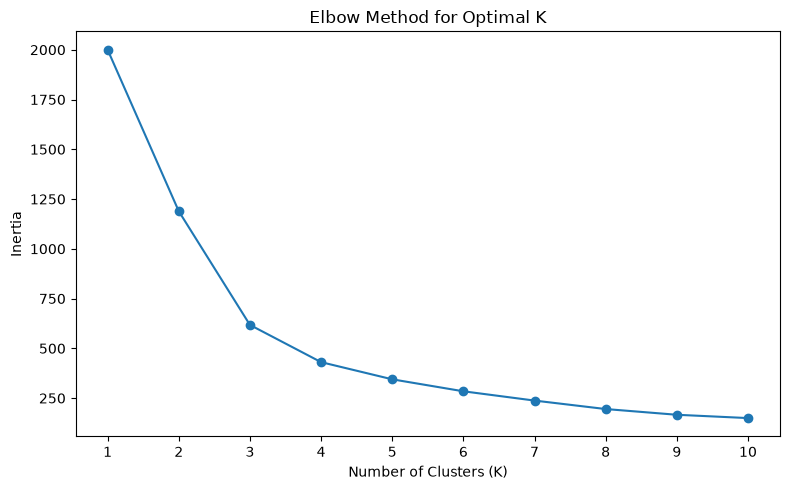

In [7]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

### Elbow Method Observation
The inertia drops sharply from K=1 to K=3, then the curve bends and flattens from K=4 onward. This "elbow" point suggests **K=4** is the optimal number of clusters — beyond this, adding more clusters gives diminishing improvement in fit.

In [8]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,CUST001,39,1,150,1
1,CUST002,309,1,1000,0
2,CUST003,354,1,30,2
3,CUST004,226,1,500,2
4,CUST005,241,1,100,2


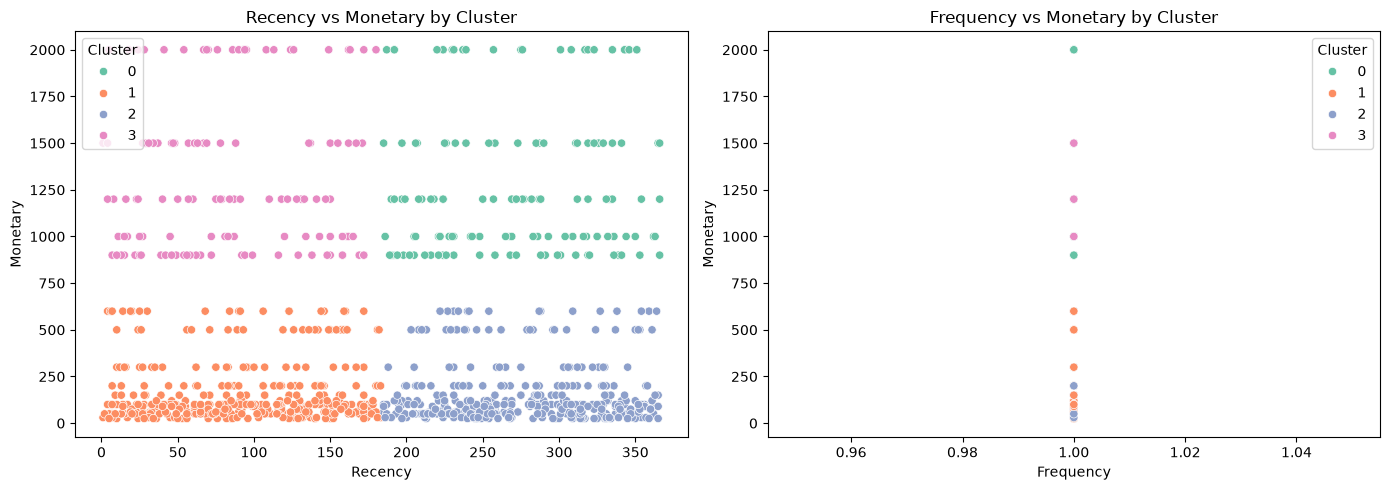

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[0])
axes[0].set_title("Recency vs Monetary by Cluster")

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="Set2", ax=axes[1])
axes[1].set_title("Frequency vs Monetary by Cluster")

plt.tight_layout()
plt.show()

In [10]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_profile["Customer Count"] = rfm["Cluster"].value_counts().sort_index()
cluster_profile

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,270.52,1.0,1283.57,140
1,92.12,1.0,159.77,370
2,274.57,1.0,148.32,366
3,84.94,1.0,1313.71,124


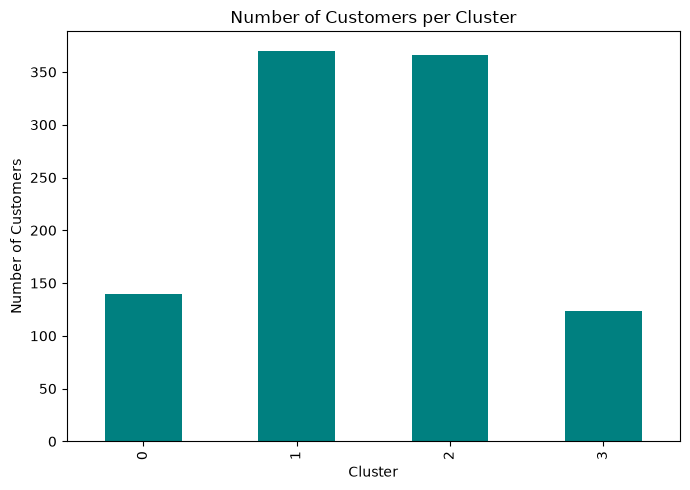

In [11]:
plt.figure(figsize=(7,5))
rfm["Cluster"].value_counts().sort_index().plot(kind="bar", color="teal")
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

The bar chart shows the majority of customers (over 700 out of 1000) fall into the two low-value clusters (1 and 2), while high-value customers (clusters 0 and 3) make up a smaller portion (~264 customers) but likely drive a disproportionate share of revenue given their much higher Monetary values. This reinforces the importance of the retention (Cluster 0) and reward (Cluster 3) strategies — protecting and growing this smaller but high-value group matters more per-customer than the larger low-value segments.

### Cluster Profiling

- **Cluster 3 — Recent High-Value Customers (124 customers):** Purchased recently (avg. 85 days ago) and spent the most (avg. ₹1,313). These are your most valuable, currently-engaged customers.
- **Cluster 0 — Lapsed High-Value Customers (140 customers):** High spenders (avg. ₹1,284) but haven't purchased in a long time (avg. 271 days). High-value customers at risk of churn.
- **Cluster 1 — Recent Low-Value Customers (370 customers):** Purchased recently (avg. 92 days ago) but spend little (avg. ₹160). Likely new or price-sensitive customers.
- **Cluster 2 — Lapsed Low-Value Customers (366 customers):** Haven't purchased in a long time (avg. 275 days) and spend the least (avg. ₹148). Likely dormant/lost customers.

Note: Frequency is uniform (1.0) across all clusters since most customers in this dataset made only a single transaction — so segmentation here is driven primarily by Recency and Monetary value.

## Insights & Marketing Recommendations

1. **Cluster 3 (Recent High-Value) — Reward & Retain:** Enroll these customers in a loyalty/VIP program with early access to new products or exclusive discounts. They're your best customers right now — the goal is to keep them engaged before they lapse.

2. **Cluster 0 (Lapsed High-Value) — Win-Back Campaign:** These customers used to spend big but have gone quiet. Send personalized "we miss you" offers or high-value discount codes to re-activate them — the potential revenue recovery per customer is high given their past spend.

3. **Cluster 1 (Recent Low-Value) — Upsell & Cross-sell:** These customers are actively engaging but spending little. Use targeted product recommendations, bundle deals, or first-time-buyer incentives to increase their average order value.

4. **Cluster 2 (Lapsed Low-Value) — Low-Cost Re-engagement or Deprioritize:** These customers are both inactive and low-spending. Rather than investing heavily, use low-cost channels (email newsletters, generic promotions) to test re-engagement — but don't over-invest here compared to Cluster 0.